# **Spam Classifier**

- Date: 2082-03-13
- Day: Friday

## Step 1: Prepare the Dataset

In [45]:
# Import the Dataset
import pandas as pd

messages = pd.read_csv("./SMSSpamCollection.txt",sep='\t',
                       names=["label","message"])

## Step 2: Visualize the dataset.

In [46]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3: - Import Necessary Libraries

1. Import Necessary Libraries [nltk, pandas, re, etc]
2. Instantiate Lemmatizer
3. Create an empty list for keeping the preprocessed text.

In [47]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

wordnet = WordNetLemmatizer()
corpus = []

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bisha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bisha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bisha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bisha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Step 4: Text Pre-processing
- Keep only Alphabet remove everything else.
- Lowercase the letters.
- Split the messages
- Apply Lemmatization (Making words that are in different forms into their base form. For eg. creative, creating, creates into create). 
- Now, joining all the messages.
- Appending messages into the empty list we created above.

In [48]:
for msg in messages['message']:
    review = re.sub('[^a-zA-Z]', ' ', msg)
    review = review.lower()
    review = review.split()
    review = [wordnet.lemmatize(word) for word in review if word not in set(stopwords.words('english'))]
    corpus.append(' '.join(review))

In [49]:
corpus[0]

'go jurong point crazy available bugis n great world la e buffet cine got amore wat'

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2500)
X = cv.fit_transform(corpus).toarray()

# Use labels from original messages (same length as corpus)
y = pd.get_dummies(messages['label'], drop_first=True).values  # spam = 1, ham = 0


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(4457, 2500) (1115, 2500) (4457, 1) (1115, 1)


In [52]:
from sklearn.naive_bayes import MultinomialNB

spam_detection_model = MultinomialNB()
spam_detection_model.fit(X_train, y_train)

y_preds = spam_detection_model.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Assuming you already have:
# y_test → true labels
# y_preds → predicted labels from model

print(f"✅ Accuracy: {accuracy_score(y_test, y_preds):.3f}")
print(f"🎯 Precision: {precision_score(y_test, y_preds):.3f}")
print(f"🔁 Recall: {recall_score(y_test, y_preds):.3f}")
print(f"⚖️ F1 Score: {f1_score(y_test, y_preds):.3f}")
print("\n🧾 Classification Report:\n", classification_report(y_test, y_preds))

✅ Accuracy: 0.985
🎯 Precision: 0.929
🔁 Recall: 0.960
⚖️ F1 Score: 0.944

🧾 Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.99      0.99       966
        True       0.93      0.96      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.97      1115
weighted avg       0.99      0.98      0.98      1115



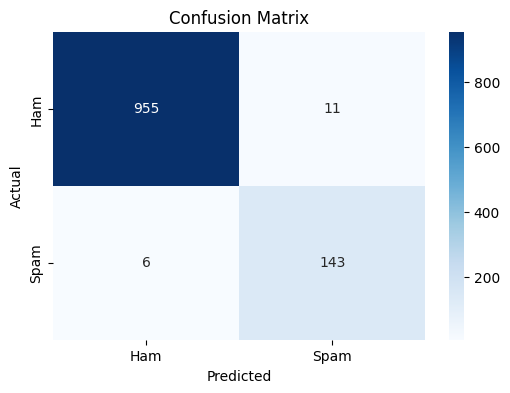

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report

# --- Confusion Matrix Plot ---
cm = confusion_matrix(y_test, y_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


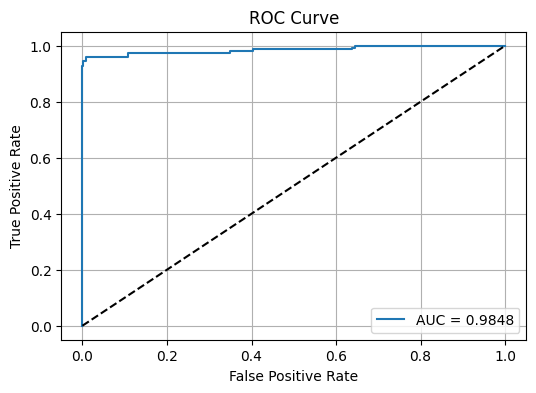

In [61]:
# Get predicted probabilities (needed for AUC/ROC)
y_probs = spam_detection_model.predict_proba(X_test)[:, 1]  # Only spam class probs

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()
